<a href="https://colab.research.google.com/github/chitwankaur20/Loan-granting/blob/main/Loan_Granting_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bank = pd.read_csv('/content/Bank_Loan_Granting.csv')
bank.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [3]:
bank.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [4]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [5]:
bank.describe()

,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [6]:
bank.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


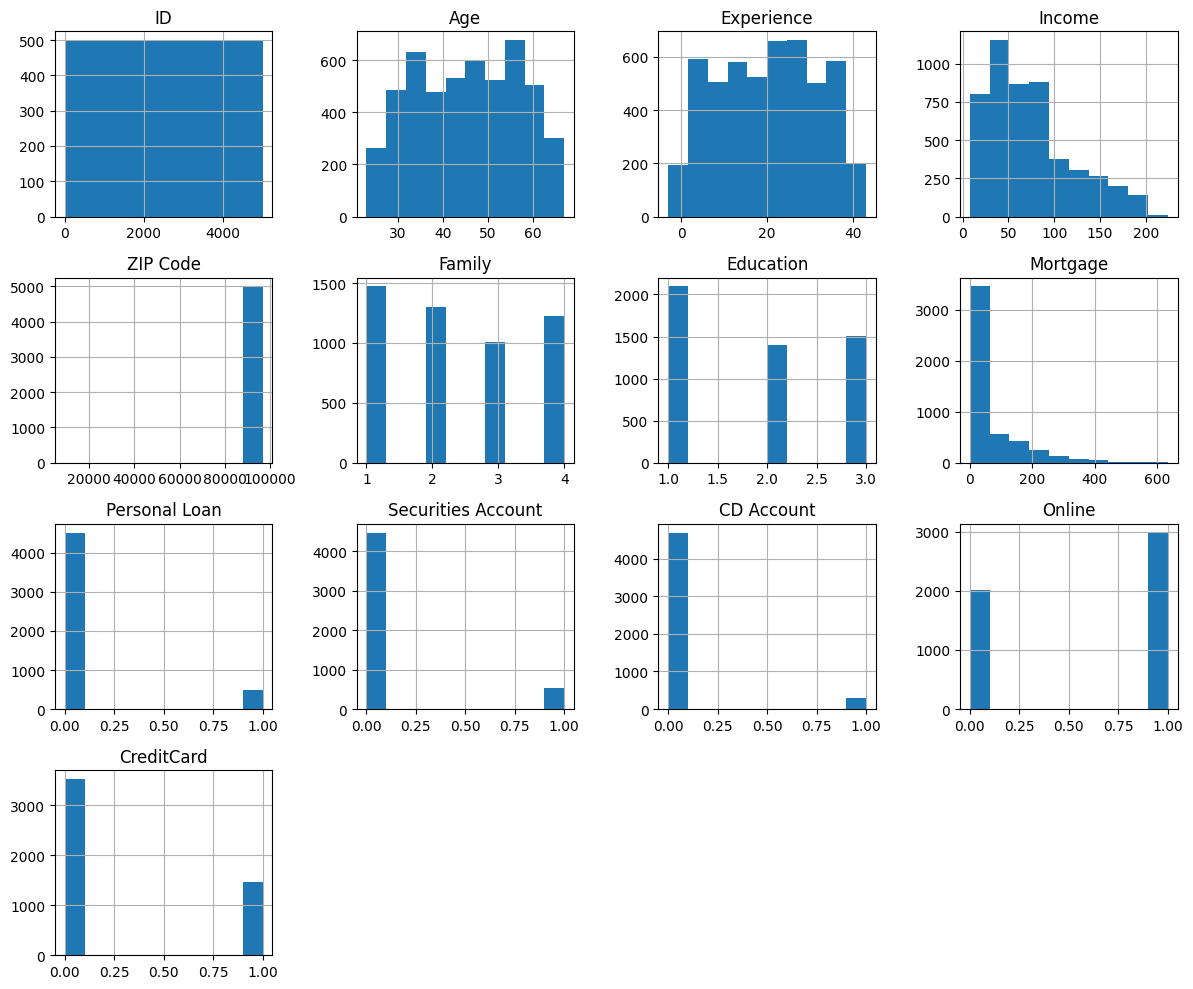

In [7]:
bank.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

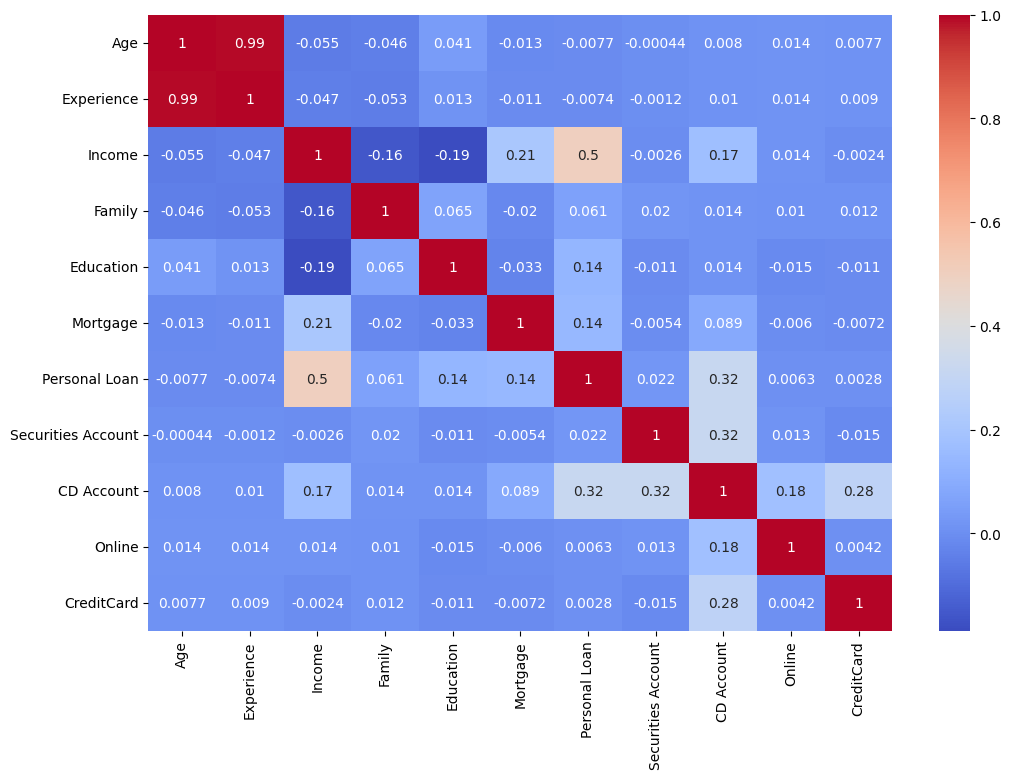

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(bank[['Age', 'Experience', 'Income', 'Family', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
bank.drop(['ID', 'ZIP Code'], axis=1, inplace=True)

In [10]:
bank['Income_Mortgage_Ratio'] = bank['Income'] / (bank['Mortgage'] + 1)

In [11]:
bank = pd.get_dummies(bank, columns=['CCAvg'])
#feature scaling
scaler = StandardScaler()
bank_scaled = scaler.fit_transform(bank)
bank_scaled

array([[-1.77441684, -1.66607847, -0.53822878, ..., -0.01414355,
        -0.020004  , -0.01414355],
       [-0.02952359, -0.09633022, -0.8641094 , ..., -0.01414355,
        -0.020004  , -0.01414355],
       [-0.55299157, -0.44516316, -1.36379301, ..., -0.01414355,
        -0.020004  , -0.01414355],
       ...,
       [ 1.54088033,  1.64783451, -1.08136314, ..., -0.01414355,
        -0.020004  , -0.01414355],
       [ 1.71536965,  1.73504275, -0.53822878, ..., -0.01414355,
        -0.020004  , -0.01414355],
       [-1.51268285, -1.40445376,  0.20043396, ..., -0.01414355,
        -0.020004  , -0.01414355]])

In [12]:
k = 2

#initialize KMeans clustering algorithm
kmeans = KMeans(n_clusters=k, random_state=42)

#KMeans
clusters = kmeans.fit_predict(bank_scaled)

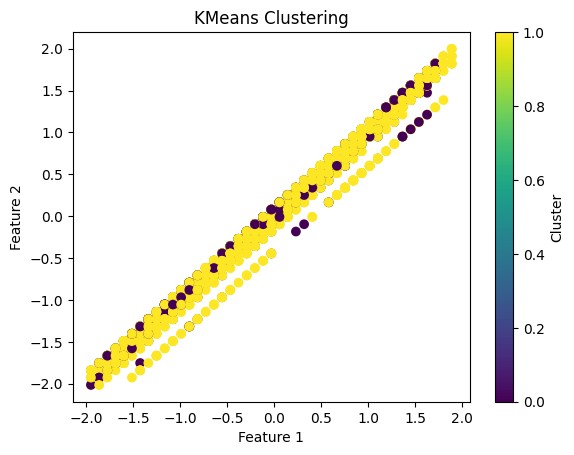

In [13]:
plt.scatter(bank_scaled[:, 0], bank_scaled[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering')
plt.colorbar(label='Cluster')
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

silhouette_score = silhouette_score(bank_scaled, clusters)
print("Silhouette Score:", silhouette_score)

Silhouette Score: 0.3036004860120829
